In [1]:
import pandas as pd
import numpy as np
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os
import json 

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
import pandas as pd
import joblib
import os

# ==========================================
# 📥 1. โหลดข้อมูลและตัวแปรที่คัดมาแล้ว
# ==========================================

# 1.1 ใส่ Path ข้อมูลของตัวเอง (แก้ path ให้ตรงกับเครื่องตัวเองนะคะ)
path = '/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/Data_Split/' 

# โหลดข้อมูล X_train, y_train, X_test, y_test เข้ามา
# (สมมติว่าตัวเองมีไฟล์ test แยกไว้แล้ว ถ้าไม่มีก็โหลดตัวเต็มมา split ใหม่ได้ค่ะ)
X_train_full = pd.read_csv(f'{path}X_train_90.csv')
y_train = pd.read_csv(f'{path}y_train_90.csv').squeeze() # .squeeze() เพื่อให้เป็น Series
X_test_full = pd.read_csv(f'{path}X_test_10.csv')      # ถ้าชื่อไฟล์ test ไม่ตรง แก้ได้เลยนะคะ
y_test = pd.read_csv(f'{path}y_test_10.csv').squeeze()

# -------------------------------------------------------
# 🔥 ไฮไลท์: โหลด "10 ตัวเทพ" ที่ RFE เลือกไว้มาใช้
# -------------------------------------------------------
# ต้องมั่นใจว่าไฟล์ pkl อยู่ในโฟลเดอร์ models หรือ path เดียวกัน
selected_features = joblib.load('models/rfe_lr_features.pkl')

print(f"✅ โหลดตัวแปรที่คัดเลือกมาแล้ว {len(selected_features)} ตัว:")
print(selected_features)

# 1.2 กรองข้อมูลให้เหลือแค่ 10 ตัวนี้
X_train = X_train_full[selected_features]
X_test = X_test_full[selected_features]

print("\n------------------------------------------------")
print(f"Shape ข้อมูลพร้อมเทรน:")
print(f"X_train: {X_train.shape}  <-- สังเกตว่าคอลัมน์จะเหลือแค่ 10")
print(f"X_test:  {X_test.shape}")
print("------------------------------------------------")

✅ โหลดตัวแปรที่คัดเลือกมาแล้ว 10 ตัว:
['Age', 'Gender', 'Smoking', 'BMI', 'High LDL Cholesterol', 'Stress Level', 'Sleep Hours', 'Sugar Consumption', 'Fasting Blood Sugar', 'Homocysteine Level']

------------------------------------------------
Shape ข้อมูลพร้อมเทรน:
X_train: (9000, 10)  <-- สังเกตว่าคอลัมน์จะเหลือแค่ 10
X_test:  (1000, 10)
------------------------------------------------


------------------------------
Baseline Model: Multi-Layer Perceptron (MLP)
------------------------------

------------------------------
Performing 5-Fold Cross-Validation...
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1: 0.8000  (80.00%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2: 0.8000  (80.00%)


...

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4: 0.8000  (80.00%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5: 0.8000  (80.00%)
------------------------------
>> Average CV Accuracy: 0.8000 (± 0.0000)
------------------------------

✓ Selected Best Model from Fold 1 (Accuracy: 0.8000)

TEST SET PERFORMANCE
Accuracy:  0.8000
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
ROC-AUC:   0.4988

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      1.00      0.89       800
     Disease       0.00      0.00      0.00       200

    accuracy                           0.80      1000
   macro avg       0.40      0.50      0.44      1000
weighted avg       0.64      0.80      0.71      1000



/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to con

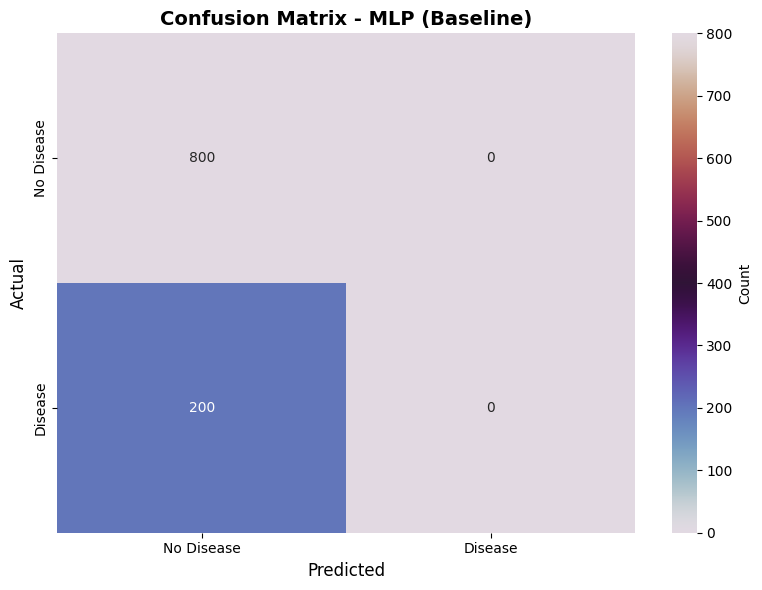


BASELINE RESULTS SUMMARY
Model               : MLP
Sampling            : None (Baseline)
CV_Accuracy         : 0.8000
CV_Std              : 0.0000
Best_Fold           : 1
Best_Fold_Val_Acc   : 0.8000
Test_Accuracy       : 0.8000
Precision           : 0.0000
Recall              : 0.0000
F1_Score            : 0.0000
ROC_AUC             : 0.4988
✓ Saved best fold model: mlp/models/MLP_baseline_bestfold.h5


In [3]:

print("-" * 30)
print('Baseline Model: Multi-Layer Perceptron (MLP)')
print("-" * 30)

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Build MLP model
def create_mlp_model(input_dim):
    model = Sequential([
        # Input Layer
        Dense(256, activation='relu', input_dim=input_dim),
        BatchNormalization(),
        Dropout(0.4),
        
        # Hidden Layer 1
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        
        # Hidden Layer 2
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        
        # Hidden Layer 3
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        
        # Hidden Layer 4
        Dense(16, activation='relu'),
        Dropout(0.2),
        
        # Output Layer
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC()]
    )
    
    return model

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# Cross-validation - Train and find best fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
cv_models = []

print("\n" + "-" * 30)
print("Performing 5-Fold Cross-Validation...")
print("-" * 30)

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel())):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # Create and train model for this fold
    model_fold = create_mlp_model(X_train.shape[1])
    model_fold.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=100,
        batch_size=32,
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
        verbose=0
    )
    
    # Evaluate
    _, accuracy, _, _, _ = model_fold.evaluate(X_val_fold, y_val_fold, verbose=0)
    cv_scores.append(accuracy)
    cv_models.append(model_fold)
    print(f"Fold {fold+1}: {accuracy:.4f}  ({accuracy*100:.2f}%)")

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print("-" * 30)

# Select best model from CV
best_fold_idx = np.argmax(cv_scores)
mlp_baseline = cv_models[best_fold_idx]
print(f"\n✓ Selected Best Model from Fold {best_fold_idx+1} (Accuracy: {cv_scores[best_fold_idx]:.4f})")

# Predictions on test set using best CV model
y_pred_proba = mlp_baseline.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Test set performance
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='twilight', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - MLP (Baseline)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary dictionary
mlp_baseline_results = {
    'Model': 'MLP',
    'Sampling': 'None (Baseline)',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Best_Fold': best_fold_idx + 1,
    'Best_Fold_Val_Acc': cv_scores[best_fold_idx],
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc
}

print("\n" + "=" * 50)
print("BASELINE RESULTS SUMMARY")
print("=" * 50)
for key, value in mlp_baseline_results.items():
    if isinstance(value, float):
        print(f"{key:20s}: {value:.4f}")
    else:
        print(f"{key:20s}: {value}")
print("=" * 50)

# Create directory
os.makedirs('mlp/models', exist_ok=True)

# Save best fold model
mlp_baseline.save('mlp/models/MLP_baseline_bestfold.h5')
print(f"✓ Saved best fold model: mlp/models/MLP_baseline_bestfold.h5")


------------------------------
MLP + SMOTE
------------------------------
Original training set size: 9000
After SMOTE training set size: 14400
Original class distribution: {0: np.int64(7200), 1: np.int64(1800)}
After SMOTE class distribution: {0: np.int64(7200), 1: np.int64(7200)}
------------------------------

------------------------------
Training MLP with SMOTE...
------------------------------

------------------------------
Performing 5-Fold Cross-Validation with SMOTE...
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This f

Fold 1: 0.5061  (50.61%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2: 0.6028  (60.28%)


...

Fold 3: 0.4961  (49.61%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4: 0.5422  (54.22%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5: 0.5439  (54.39%)
------------------------------
>> Average CV Accuracy: 0.5382 (± 0.0375)
------------------------------

✓ Selected Best Model from Fold 2 (Accuracy: 0.6028)

TEST SET PERFORMANCE (SMOTE)
Accuracy:  0.5830
Precision: 0.2107
Recall:    0.3950
F1-Score:  0.2748
ROC-AUC:   0.5174

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.81      0.63      0.71       800
     Disease       0.21      0.40      0.27       200

    accuracy                           0.58      1000
   macro avg       0.51      0.51      0.49      1000
weighted avg       0.69      0.58      0.62      1000



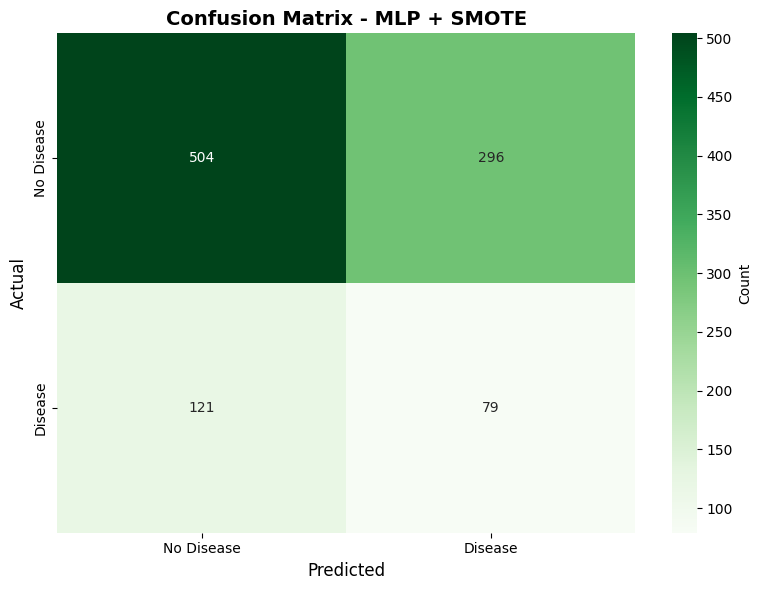


SMOTE RESULTS SUMMARY
Model               : MLP
Sampling            : SMOTE
CV_Accuracy         : 0.5382
CV_Std              : 0.0375
Best_Fold           : 2
Best_Fold_Val_Acc   : 0.6028
Test_Accuracy       : 0.5830
Precision           : 0.2107
Recall              : 0.3950
F1_Score            : 0.2748
ROC_AUC             : 0.5174
✓ Saved best fold model: mlp/models/MLP_smote_bestfold.h5
✓ Saved: mlp/models/smote_sampler_mlp.pkl


In [4]:
from imblearn.over_sampling import SMOTE

print("-" * 30)
print('MLP + SMOTE')
print("-" * 30)

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train.values.ravel())

print(f"Original training set size: {len(X_train)}")
print(f"After SMOTE training set size: {len(X_train_smote)}")
print(f"Original class distribution: {dict(pd.Series(y_train.values.ravel()).value_counts())}")
print(f"After SMOTE class distribution: {dict(pd.Series(y_train_smote).value_counts())}")
print("-" * 30)

# Create model
mlp_smote = create_mlp_model(X_train.shape[1])

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

print("\n" + "-" * 30)
print("Training MLP with SMOTE...")
print("-" * 30)

# Cross-validation with SMOTE
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
cv_models = []

print("\n" + "-" * 30)
print("Performing 5-Fold Cross-Validation with SMOTE...")
print("-" * 30)

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel())):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # Apply SMOTE
    X_train_fold_smote, y_train_fold_smote = smote.fit_resample(X_train_fold, y_train_fold)
    
    # Create and train model
    model_fold = create_mlp_model(X_train.shape[1])
    model_fold.fit(
        X_train_fold_smote, y_train_fold_smote,
        validation_data=(X_val_fold, y_val_fold),
        epochs=100,
        batch_size=32,
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
        verbose=0
    )
    
    # Evaluate
    _, accuracy, _, _, _ = model_fold.evaluate(X_val_fold, y_val_fold, verbose=0)
    cv_scores.append(accuracy)
    cv_models.append(model_fold)
    print(f"Fold {fold+1}: {accuracy:.4f}  ({accuracy*100:.2f}%)")

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print("-" * 30)

# Select best model from CV
best_fold_idx = np.argmax(cv_scores)
mlp_smote = cv_models[best_fold_idx]
print(f"\n✓ Selected Best Model from Fold {best_fold_idx+1} (Accuracy: {cv_scores[best_fold_idx]:.4f})")

# Predictions using best CV model
y_pred_proba = mlp_smote.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Test set performance
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (SMOTE)")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - MLP + SMOTE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary dictionary
mlp_smote_results = {
    'Model': 'MLP',
    'Sampling': 'SMOTE',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Best_Fold': best_fold_idx + 1,
    'Best_Fold_Val_Acc': cv_scores[best_fold_idx],
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc
}

print("\n" + "=" * 50)
print("SMOTE RESULTS SUMMARY")
print("=" * 50)
for key, value in mlp_smote_results.items():
    if isinstance(value, float):
        print(f"{key:20s}: {value:.4f}")
    else:
        print(f"{key:20s}: {value}")
print("=" * 50)

# Save best fold model
mlp_smote.save('mlp/models/MLP_smote_bestfold.h5')
joblib.dump(smote, 'mlp/models/smote_sampler_mlp.pkl')
print(f"✓ Saved best fold model: mlp/models/MLP_smote_bestfold.h5")
print("✓ Saved: mlp/models/smote_sampler_mlp.pkl")

------------------------------
MLP + ADASYN
------------------------------
Original training set size: 9000
After ADASYN training set size: 14431
Original class distribution: {0: np.int64(7200), 1: np.int64(1800)}
After ADASYN class distribution: {1: np.int64(7231), 0: np.int64(7200)}
------------------------------

------------------------------
Training MLP with ADASYN...
------------------------------

------------------------------
Performing 5-Fold Cross-Validation with ADASYN...
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This f

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1: 0.5183  (51.83%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Fold 3: 0.5456  (54.56%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4: 0.5394  (53.94%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5: 0.5272  (52.72%)
------------------------------
>> Average CV Accuracy: 0.5338 (± 0.0097)
------------------------------

✓ Selected Best Model from Fold 3 (Accuracy: 0.5456)

TEST SET PERFORMANCE (ADASYN)
Accuracy:  0.5220
Precision: 0.2116
Recall:    0.5100
F1-Score:  0.2991
ROC-AUC:   0.5263

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.81      0.53      0.64       800
     Disease       0.21      0.51      0.30       200

    accuracy                           0.52      1000
   macro avg       0.51      0.52      0.47      1000
weighted avg       0.69      0.52      0.57      1000



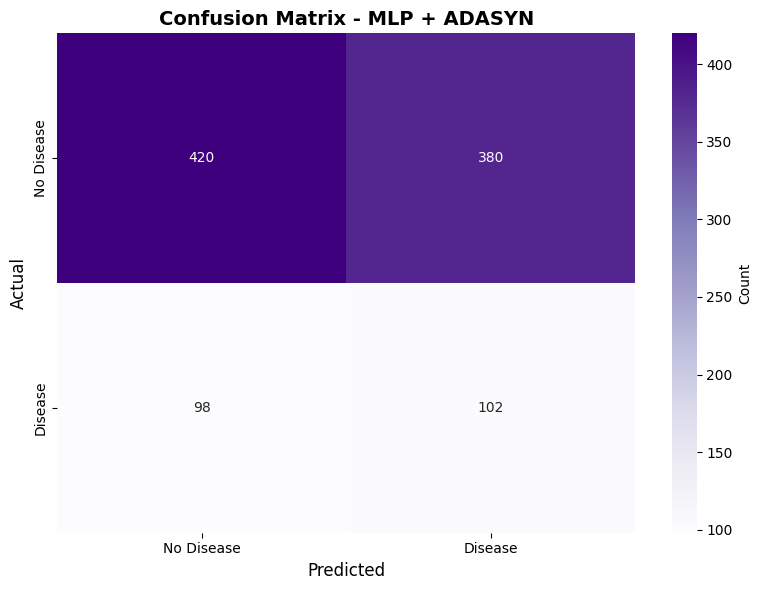


ADASYN RESULTS SUMMARY
Model               : MLP
Sampling            : ADASYN
CV_Accuracy         : 0.5338
CV_Std              : 0.0097
Best_Fold           : 3
Best_Fold_Val_Acc   : 0.5456
Test_Accuracy       : 0.5220
Precision           : 0.2116
Recall              : 0.5100
F1_Score            : 0.2991
ROC_AUC             : 0.5263
✓ Saved best fold model: mlp/models/MLP_adasyn_bestfold.h5
✓ Saved: mlp/models/adasyn_sampler_mlp.pkl


In [5]:
from imblearn.over_sampling import ADASYN

print("-" * 30)
print('MLP + ADASYN')
print("-" * 30)

# Initialize ADASYN
adasyn = ADASYN(random_state=42, n_neighbors=5)

# Apply ADASYN to training data
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train.values.ravel())

print(f"Original training set size: {len(X_train)}")
print(f"After ADASYN training set size: {len(X_train_adasyn)}")
print(f"Original class distribution: {dict(pd.Series(y_train.values.ravel()).value_counts())}")
print(f"After ADASYN class distribution: {dict(pd.Series(y_train_adasyn).value_counts())}")
print("-" * 30)

# Create model
mlp_adasyn = create_mlp_model(X_train.shape[1])

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

print("\n" + "-" * 30)
print("Training MLP with ADASYN...")
print("-" * 30)

# Cross-validation with ADASYN
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
cv_models = []

print("\n" + "-" * 30)
print("Performing 5-Fold Cross-Validation with ADASYN...")
print("-" * 30)

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel())):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    try:
        # Apply ADASYN
        X_train_fold_adasyn, y_train_fold_adasyn = adasyn.fit_resample(X_train_fold, y_train_fold)
        
        # Create and train model
        model_fold = create_mlp_model(X_train.shape[1])
        model_fold.fit(
            X_train_fold_adasyn, y_train_fold_adasyn,
            validation_data=(X_val_fold, y_val_fold),
            epochs=100,
            batch_size=32,
            callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
            verbose=0
        )
        
        # Evaluate
        _, accuracy, _, _, _ = model_fold.evaluate(X_val_fold, y_val_fold, verbose=0)
        cv_scores.append(accuracy)
        cv_models.append(model_fold)
        print(f"Fold {fold+1}: {accuracy:.4f}  ({accuracy*100:.2f}%)")
    except ValueError as e:
        print(f"Warning in fold {fold+1}: {e}")
        continue

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print("-" * 30)

# Select best model from CV
if len(cv_models) > 0:
    best_fold_idx = np.argmax(cv_scores)
    mlp_adasyn = cv_models[best_fold_idx]
    print(f"\n✓ Selected Best Model from Fold {best_fold_idx+1} (Accuracy: {cv_scores[best_fold_idx]:.4f})")
else:
    # Fallback to full training if CV failed
    mlp_adasyn = create_mlp_model(X_train.shape[1])
    mlp_adasyn.fit(X_train_adasyn, y_train_adasyn, validation_split=0.2, epochs=100, batch_size=32, 
                   callbacks=[early_stopping, reduce_lr], verbose=0)
    best_fold_idx = 0

# Predictions using best CV model
y_pred_proba = mlp_adasyn.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Test set performance
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (ADASYN)")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - MLP + ADASYN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary dictionary
mlp_adasyn_results = {
    'Model': 'MLP',
    'Sampling': 'ADASYN',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Best_Fold': best_fold_idx + 1,
    'Best_Fold_Val_Acc': cv_scores[best_fold_idx] if len(cv_scores) > 0 else 0,
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc
}

print("\n" + "=" * 50)
print("ADASYN RESULTS SUMMARY")
print("=" * 50)
for key, value in mlp_adasyn_results.items():
    if isinstance(value, float):
        print(f"{key:20s}: {value:.4f}")
    else:
        print(f"{key:20s}: {value}")
print("=" * 50)

# Save best fold model
mlp_adasyn.save('mlp/models/MLP_adasyn_bestfold.h5')
joblib.dump(adasyn, 'mlp/models/adasyn_sampler_mlp.pkl')
print(f"✓ Saved best fold model: mlp/models/MLP_adasyn_bestfold.h5")
print("✓ Saved: mlp/models/adasyn_sampler_mlp.pkl")

------------------------------
MLP + RandomUnderSampler
------------------------------
Original training set size: 9000
After RUS training set size: 3600
Original class distribution: {0: np.int64(7200), 1: np.int64(1800)}
After RUS class distribution: {0: np.int64(1800), 1: np.int64(1800)}
------------------------------

------------------------------
Training MLP with RUS...
------------------------------

------------------------------
Performing 5-Fold Cross-Validation with RUS...
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/tanananyathongkum/Jenny/Project/Heart 

Fold 1: 0.5283  (52.83%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2: 0.7128  (71.28%)


...

Fold 3: 0.7533  (75.33%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4: 0.7956  (79.56%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5: 0.7172  (71.72%)
------------------------------
>> Average CV Accuracy: 0.7014 (± 0.0915)
------------------------------

✓ Selected Best Model from Fold 4 (Accuracy: 0.7956)

TEST SET PERFORMANCE (RUS)
Accuracy:  0.7970
Precision: 0.2857
Recall:    0.0100
F1-Score:  0.0193
ROC-AUC:   0.5378

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      0.99      0.89       800
     Disease       0.29      0.01      0.02       200

    accuracy                           0.80      1000
   macro avg       0.54      0.50      0.45      1000
weighted avg       0.70      0.80      0.71      1000



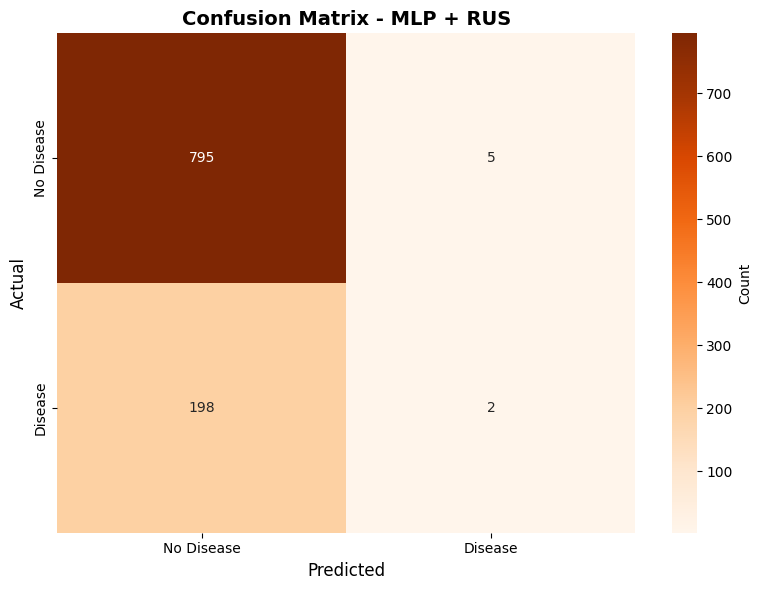


RUS RESULTS SUMMARY
Model               : MLP
Sampling            : RandomUnderSampler
CV_Accuracy         : 0.7014
CV_Std              : 0.0915
Best_Fold           : 4
Best_Fold_Val_Acc   : 0.7956
Test_Accuracy       : 0.7970
Precision           : 0.2857
Recall              : 0.0100
F1_Score            : 0.0193
ROC_AUC             : 0.5378
✓ Saved best fold model: mlp/models/MLP_rus_bestfold.h5
✓ Saved: mlp/models/rus_sampler_mlp.pkl


In [6]:
from imblearn.under_sampling import RandomUnderSampler

print("-" * 30)
print('MLP + RandomUnderSampler')
print("-" * 30)

# Initialize RUS
rus = RandomUnderSampler(random_state=42)

# Apply RUS to training data
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train.values.ravel())

print(f"Original training set size: {len(X_train)}")
print(f"After RUS training set size: {len(X_train_rus)}")
print(f"Original class distribution: {dict(pd.Series(y_train.values.ravel()).value_counts())}")
print(f"After RUS class distribution: {dict(pd.Series(y_train_rus).value_counts())}")
print("-" * 30)

# Create model
mlp_rus = create_mlp_model(X_train.shape[1])

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

print("\n" + "-" * 30)
print("Training MLP with RUS...")
print("-" * 30)

# Cross-validation with RUS
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
cv_models = []

print("\n" + "-" * 30)
print("Performing 5-Fold Cross-Validation with RUS...")
print("-" * 30)

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel())):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # Apply RUS
    X_train_fold_rus, y_train_fold_rus = rus.fit_resample(X_train_fold, y_train_fold)
    
    # Create and train model
    model_fold = create_mlp_model(X_train.shape[1])
    model_fold.fit(
        X_train_fold_rus, y_train_fold_rus,
        validation_data=(X_val_fold, y_val_fold),
        epochs=100,
        batch_size=32,
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
        verbose=0
    )
    
    # Evaluate
    _, accuracy, _, _, _ = model_fold.evaluate(X_val_fold, y_val_fold, verbose=0)
    cv_scores.append(accuracy)
    cv_models.append(model_fold)
    print(f"Fold {fold+1}: {accuracy:.4f}  ({accuracy*100:.2f}%)")

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print("-" * 30)

# Select best model from CV
best_fold_idx = np.argmax(cv_scores)
mlp_rus = cv_models[best_fold_idx]
print(f"\n✓ Selected Best Model from Fold {best_fold_idx+1} (Accuracy: {cv_scores[best_fold_idx]:.4f})")

# Predictions using best CV model
y_pred_proba = mlp_rus.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Test set performance
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (RUS)")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - MLP + RUS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary dictionary
mlp_rus_results = {
    'Model': 'MLP',
    'Sampling': 'RandomUnderSampler',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Best_Fold': best_fold_idx + 1,
    'Best_Fold_Val_Acc': cv_scores[best_fold_idx],
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc
}

print("\n" + "=" * 50)
print("RUS RESULTS SUMMARY")
print("=" * 50)
for key, value in mlp_rus_results.items():
    if isinstance(value, float):
        print(f"{key:20s}: {value:.4f}")
    else:
        print(f"{key:20s}: {value}")
print("=" * 50)

# Save best fold model
mlp_rus.save('mlp/models/MLP_rus_bestfold.h5')
joblib.dump(rus, 'mlp/models/rus_sampler_mlp.pkl')
print(f"✓ Saved best fold model: mlp/models/MLP_rus_bestfold.h5")
print("✓ Saved: mlp/models/rus_sampler_mlp.pkl")

------------------------------
MLP + NearMiss
------------------------------
Resampling with NearMiss...


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Original size: 9000
After NearMiss size: 3600
------------------------------
Performing Cross-Validation...


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1: 0.8083


...


Epoch 78: ReduceLROnPlateau reducing learning rate to 3.906250185536919e-06.



Epoch 83: ReduceLROnPlateau reducing learning rate to 1.9531250927684596e-06.


Epoch 83: early stopping


Restoring model weights from the end of the best epoch: 68.



TEST SET PERFORMANCE (NearMiss)
Accuracy:  0.4790
Precision: 0.2118
Recall:    0.5900
F1-Score:  0.3118
ROC-AUC:   0.5180


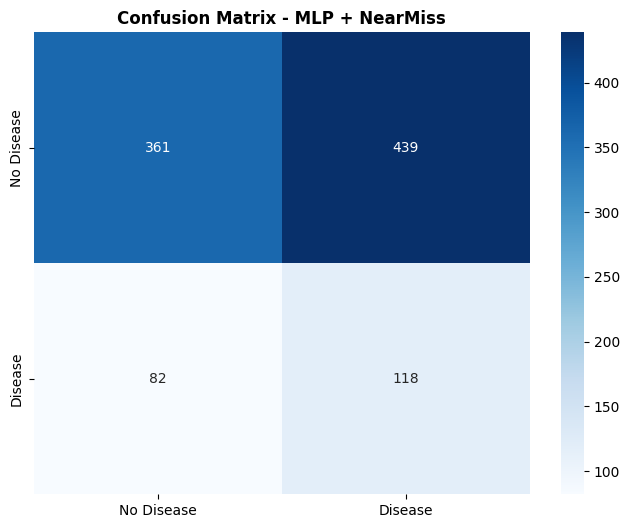

✓ Saved models


In [7]:
from imblearn.under_sampling import NearMiss

print("-" * 30)
print('MLP + NearMiss')
print("-" * 30)

# --- 1. Prepare Data as Numpy Arrays ---
X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
y_train_np = y_train.values.ravel() if hasattr(y_train, 'values') else y_train
X_test_np = X_test.values if hasattr(X_test, 'values') else X_test
y_test_np = y_test.values.ravel() if hasattr(y_test, 'values') else y_test

# --- 2. Apply NearMiss ---
nm = NearMiss(version=2)
print("Resampling with NearMiss...")
X_train_nm, y_train_nm = nm.fit_resample(X_train_np, y_train_np)

print(f"Original size: {len(X_train_np)}")
print(f"After NearMiss size: {len(X_train_nm)}")
print("-" * 30)

# --- 3. Cross-Validation ---
cv_scores = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Performing Cross-Validation...")
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_nm, y_train_nm), 1):
    X_cv_train, X_cv_val = X_train_nm[train_idx], X_train_nm[val_idx]
    y_cv_train, y_cv_val = y_train_nm[train_idx], y_train_nm[val_idx]
    
    # Create & Train
    model_fold = create_mlp_model(X_train.shape[1])
    model_fold.fit(
        X_cv_train, y_cv_train,
        validation_data=(X_cv_val, y_cv_val),
        epochs=50, batch_size=32,
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
        verbose=0
    )
    
    # Evaluate (Index 1 is accuracy)
    eval_res = model_fold.evaluate(X_cv_val, y_cv_val, verbose=0)
    cv_scores.append(eval_res[1])
    print(f"Fold {fold}: {eval_res[1]:.4f}")

print(f">> Average CV Accuracy: {np.mean(cv_scores):.4f}")
print("-" * 30)

# --- 4. Full Training ---
print("Training MLP with NearMiss (Full)...")
mlp_nm = create_mlp_model(X_train.shape[1])
history_nm = mlp_nm.fit(
    X_train_nm, y_train_nm,
    validation_split=0.2,
    epochs=100, batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=0
)

# --- 5. Evaluation ---
eval_res = mlp_nm.evaluate(X_test_np, y_test_np, verbose=0)
test_accuracy = eval_res[1]

y_pred_proba = mlp_nm.predict(X_test_np, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

test_precision = precision_score(y_test_np, y_pred)
test_recall = recall_score(y_test_np, y_pred)
test_f1 = f1_score(y_test_np, y_pred)
test_roc_auc = roc_auc_score(y_test_np, y_pred_proba)

# Show Results
print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (NearMiss)")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test_np, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - MLP + NearMiss', fontweight='bold')
plt.show()

# Save Results
mlp_nearmiss_results = {
    'Model': 'MLP', 'Sampling': 'NearMiss',
    'CV_Accuracy': np.mean(cv_scores), 'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy, 'Precision': test_precision,
    'Recall': test_recall, 'F1_Score': test_f1, 'ROC_AUC': test_roc_auc
}

mlp_nm.save('mlp/models/MLP_nearmiss.h5')
joblib.dump(nm, 'mlp/models/nearmiss_sampler_mlp.pkl')
print("✓ Saved models")

------------------------------
MLP + Cluster Centroids
------------------------------
Resampling... (This may take a while ⏳)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Original size: 9000
After CC size: 3600
------------------------------
Performing Cross-Validation...


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1: 0.5056


...


Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.



Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


Epoch 16: early stopping


Restoring model weights from the end of the best epoch: 1.



TEST SET PERFORMANCE (Cluster Centroids)
Accuracy:  0.7850
Precision: 0.1429
Recall:    0.0150
F1-Score:  0.0271
ROC-AUC:   0.4702


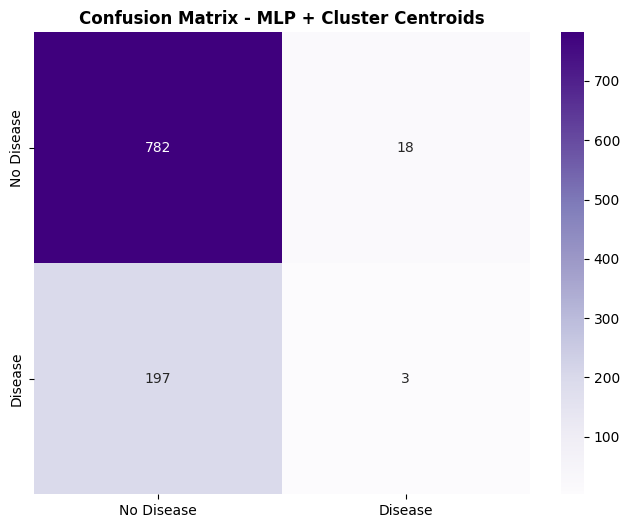

✓ Saved models


In [8]:
from imblearn.under_sampling import ClusterCentroids

print("-" * 30)
print('MLP + Cluster Centroids')
print("-" * 30)

# --- 1. Apply Cluster Centroids ---
cc = ClusterCentroids(random_state=42)
print("Resampling... (This may take a while ⏳)")
X_train_cc, y_train_cc = cc.fit_resample(X_train_np, y_train_np)

print(f"Original size: {len(X_train_np)}")
print(f"After CC size: {len(X_train_cc)}")
print("-" * 30)

# --- 2. Cross-Validation ---
cv_scores = []
print("Performing Cross-Validation...")
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_cc, y_train_cc), 1):
    X_cv_train, X_cv_val = X_train_cc[train_idx], X_train_cc[val_idx]
    y_cv_train, y_cv_val = y_train_cc[train_idx], y_train_cc[val_idx]
    
    model_fold = create_mlp_model(X_train.shape[1])
    model_fold.fit(
        X_cv_train, y_cv_train,
        validation_data=(X_cv_val, y_cv_val),
        epochs=50, batch_size=32,
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
        verbose=0
    )
    eval_res = model_fold.evaluate(X_cv_val, y_cv_val, verbose=0)
    cv_scores.append(eval_res[1])
    print(f"Fold {fold}: {eval_res[1]:.4f}")

print(f">> Average CV Accuracy: {np.mean(cv_scores):.4f}")
print("-" * 30)

# --- 3. Full Training ---
print("Training MLP with Cluster Centroids (Full)...")
mlp_cc = create_mlp_model(X_train.shape[1])
history_cc = mlp_cc.fit(
    X_train_cc, y_train_cc,
    validation_split=0.2,
    epochs=100, batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=0
)

# --- 4. Evaluation ---
eval_res = mlp_cc.evaluate(X_test_np, y_test_np, verbose=0)
test_accuracy = eval_res[1]

y_pred_proba = mlp_cc.predict(X_test_np, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

test_precision = precision_score(y_test_np, y_pred)
test_recall = recall_score(y_test_np, y_pred)
test_f1 = f1_score(y_test_np, y_pred)
test_roc_auc = roc_auc_score(y_test_np, y_pred_proba)

# Show Results
print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (Cluster Centroids)")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test_np, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - MLP + Cluster Centroids', fontweight='bold')
plt.show()

# Save Results
mlp_cc_results = {
    'Model': 'MLP', 'Sampling': 'ClusterCentroids',
    'CV_Accuracy': np.mean(cv_scores), 'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy, 'Precision': test_precision,
    'Recall': test_recall, 'F1_Score': test_f1, 'ROC_AUC': test_roc_auc
}

mlp_cc.save('mlp/models/MLP_cc.h5')
joblib.dump(cc, 'mlp/models/cc_sampler_mlp.pkl')
print("✓ Saved models")

------------------------------
MLP + SMOTETomek
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Original training set size: 9000
After SMOTETomek training set size: 14162
Original class distribution: {0: np.int64(7200), 1: np.int64(1800)}
After SMOTETomek class distribution: {0: np.int64(7081), 1: np.int64(7081)}
------------------------------

------------------------------
Performing 5-Fold Cross-Validation with SMOTETomek...
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This f

Fold 1: 0.3744  (37.44%)


...

Fold 3: 0.5600  (56.00%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 4: 0.5106  (51.06%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 5: 0.5250  (52.50%)
------------------------------
>> Average CV Accuracy: 0.5079 (± 0.0702)
------------------------------

✓ Selected Best Model from Fold 2 (Accuracy: 0.5694)

TEST SET PERFORMANCE (SMOTETomek)
Accuracy:  0.5450
Precision: 0.1971
Recall:    0.4150
F1-Score:  0.2673
ROC-AUC:   0.5078

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      0.58      0.67       800
     Disease       0.20      0.41      0.27       200

    accuracy                           0.55      1000
   macro avg       0.50      0.50      0.47      1000
weighted avg       0.68      0.55      0.59      1000



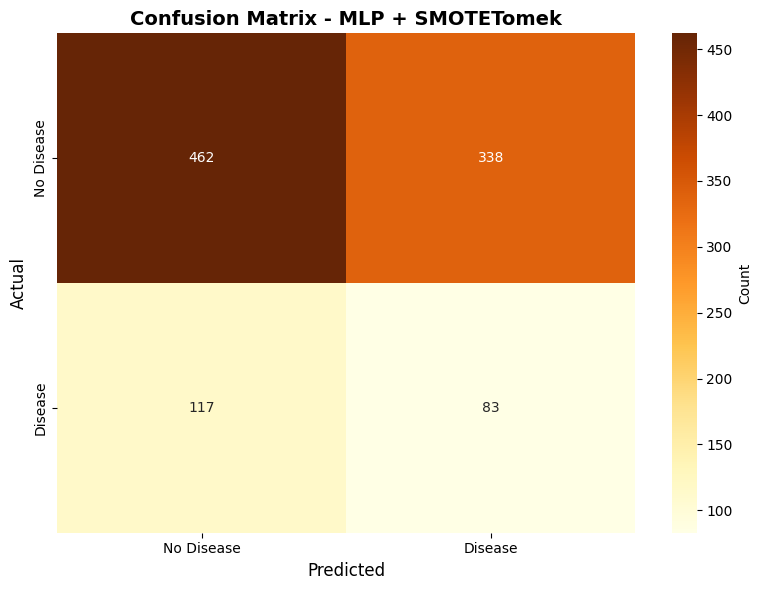


SMOTETomek RESULTS SUMMARY
Model               : MLP
Sampling            : SMOTETomek
CV_Accuracy         : 0.5079
CV_Std              : 0.0702
Best_Fold           : 2
Best_Fold_Val_Acc   : 0.5694
Test_Accuracy       : 0.5450
Precision           : 0.1971
Recall              : 0.4150
F1_Score            : 0.2673
ROC_AUC             : 0.5078
✓ Saved best fold model: mlp/models/MLP_smote_tomek_bestfold.h5
✓ Saved: mlp/models/smote_tomek_sampler_mlp.pkl


In [9]:
from imblearn.combine import SMOTETomek

print("-" * 30)
print('MLP + SMOTETomek')
print("-" * 30)

# Initialize SMOTETomek
smote_tomek = SMOTETomek(random_state=42)

# Apply SMOTETomek to training data
X_train_smote_tomek, y_train_smote_tomek = smote_tomek.fit_resample(X_train, y_train.values.ravel())

print(f"Original training set size: {len(X_train)}")
print(f"After SMOTETomek training set size: {len(X_train_smote_tomek)}")
print(f"Original class distribution: {dict(pd.Series(y_train.values.ravel()).value_counts())}")
print(f"After SMOTETomek class distribution: {dict(pd.Series(y_train_smote_tomek).value_counts())}")
print("-" * 30)

# Create model
mlp_smote_tomek = create_mlp_model(X_train.shape[1])

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# Cross-validation with SMOTETomek
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
cv_models = []

print("\n" + "-" * 30)
print("Performing 5-Fold Cross-Validation with SMOTETomek...")
print("-" * 30)

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel())):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # Apply SMOTETomek
    X_train_fold_smote_tomek, y_train_fold_smote_tomek = smote_tomek.fit_resample(X_train_fold, y_train_fold)
    
    # Create and train model
    model_fold = create_mlp_model(X_train.shape[1])
    model_fold.fit(
        X_train_fold_smote_tomek, y_train_fold_smote_tomek,
        validation_data=(X_val_fold, y_val_fold),
        epochs=100,
        batch_size=32,
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
        verbose=0
    )
    
    # Evaluate
    _, accuracy, _, _, _ = model_fold.evaluate(X_val_fold, y_val_fold, verbose=0)
    cv_scores.append(accuracy)
    cv_models.append(model_fold)
    print(f"Fold {fold+1}: {accuracy:.4f}  ({accuracy*100:.2f}%)")

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print("-" * 30)

# Select best model from CV
best_fold_idx = np.argmax(cv_scores)
mlp_smote_tomek = cv_models[best_fold_idx]
print(f"\n✓ Selected Best Model from Fold {best_fold_idx+1} (Accuracy: {cv_scores[best_fold_idx]:.4f})")

# Predictions using best CV model
y_pred_proba = mlp_smote_tomek.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Test set performance
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (SMOTETomek)")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='YlOrBr', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - MLP + SMOTETomek', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary dictionary
mlp_smote_tomek_results = {
    'Model': 'MLP',
    'Sampling': 'SMOTETomek',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Best_Fold': best_fold_idx + 1,
    'Best_Fold_Val_Acc': cv_scores[best_fold_idx],
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc
}

print("\n" + "=" * 50)
print("SMOTETomek RESULTS SUMMARY")
print("=" * 50)
for key, value in mlp_smote_tomek_results.items():
    if isinstance(value, float):
        print(f"{key:20s}: {value:.4f}")
    else:
        print(f"{key:20s}: {value}")
print("=" * 50)

# Save best fold model
mlp_smote_tomek.save('mlp/models/MLP_smote_tomek_bestfold.h5')
joblib.dump(smote_tomek, 'mlp/models/smote_tomek_sampler_mlp.pkl')
print(f"✓ Saved best fold model: mlp/models/MLP_smote_tomek_bestfold.h5")
print("✓ Saved: mlp/models/smote_tomek_sampler_mlp.pkl")

------------------------------
MLP + SMOTEENN
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Original training set size: 9000
After SMOTEENN training set size: 8907
Original class distribution: {0: np.int64(7200), 1: np.int64(1800)}
After SMOTEENN class distribution: {1: np.int64(5911), 0: np.int64(2996)}
------------------------------

------------------------------
Performing 5-Fold Cross-Validation with SMOTEENN...
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This f

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4: 0.2039  (20.39%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5: 0.2000  (20.00%)
------------------------------
>> Average CV Accuracy: 0.2087 (± 0.0093)
------------------------------

✓ Selected Best Model from Fold 3 (Accuracy: 0.2222)

TEST SET PERFORMANCE (SMOTEENN)
Accuracy:  0.2280
Precision: 0.2021
Recall:    0.9700
F1-Score:  0.3345
ROC-AUC:   0.4989

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.85      0.04      0.08       800
     Disease       0.20      0.97      0.33       200

    accuracy                           0.23      1000
   macro avg       0.53      0.51      0.21      1000
weighted avg       0.72      0.23      0.13      1000



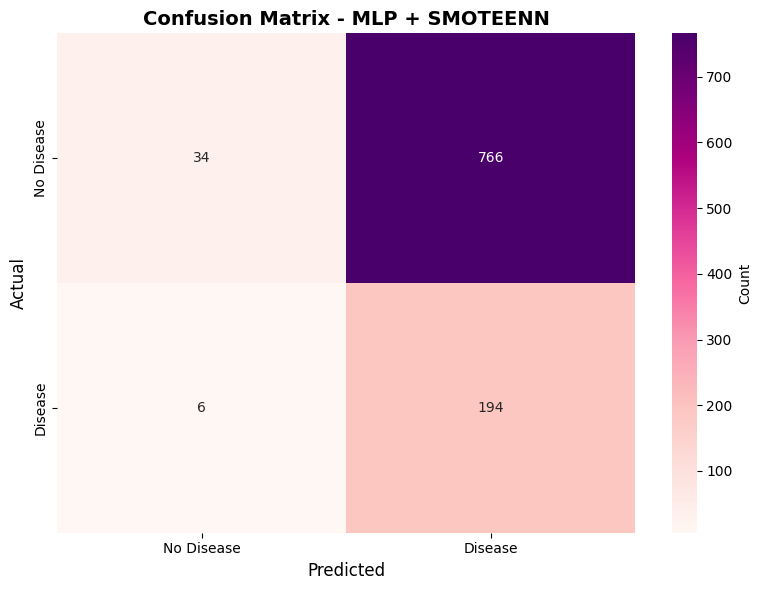


SMOTEENN RESULTS SUMMARY
Model               : MLP
Sampling            : SMOTEENN
CV_Accuracy         : 0.2087
CV_Std              : 0.0093
Best_Fold           : 3
Best_Fold_Val_Acc   : 0.2222
Test_Accuracy       : 0.2280
Precision           : 0.2021
Recall              : 0.9700
F1_Score            : 0.3345
ROC_AUC             : 0.4989
✓ Saved best fold model: mlp/models/MLP_smote_enn_bestfold.h5
✓ Saved: mlp/models/smote_enn_sampler_mlp.pkl


In [10]:
from imblearn.combine import SMOTEENN

print("-" * 30)
print('MLP + SMOTEENN')
print("-" * 30)

# Initialize SMOTEENN
smote_enn = SMOTEENN(random_state=42)

# Apply SMOTEENN to training data
X_train_smote_enn, y_train_smote_enn = smote_enn.fit_resample(X_train, y_train.values.ravel())

print(f"Original training set size: {len(X_train)}")
print(f"After SMOTEENN training set size: {len(X_train_smote_enn)}")
print(f"Original class distribution: {dict(pd.Series(y_train.values.ravel()).value_counts())}")
print(f"After SMOTEENN class distribution: {dict(pd.Series(y_train_smote_enn).value_counts())}")
print("-" * 30)

# Create model
mlp_smote_enn = create_mlp_model(X_train.shape[1])

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# Cross-validation with SMOTEENN
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
cv_models = []

print("\n" + "-" * 30)
print("Performing 5-Fold Cross-Validation with SMOTEENN...")
print("-" * 30)

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel())):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # Apply SMOTEENN
    X_train_fold_smote_enn, y_train_fold_smote_enn = smote_enn.fit_resample(X_train_fold, y_train_fold)
    
    # Create and train model
    model_fold = create_mlp_model(X_train.shape[1])
    model_fold.fit(
        X_train_fold_smote_enn, y_train_fold_smote_enn,
        validation_data=(X_val_fold, y_val_fold),
        epochs=100,
        batch_size=32,
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
        verbose=0
    )
    
    # Evaluate
    _, accuracy, _, _, _ = model_fold.evaluate(X_val_fold, y_val_fold, verbose=0)
    cv_scores.append(accuracy)
    cv_models.append(model_fold)
    print(f"Fold {fold+1}: {accuracy:.4f}  ({accuracy*100:.2f}%)")

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print("-" * 30)

# Select best model from CV
best_fold_idx = np.argmax(cv_scores)
mlp_smote_enn = cv_models[best_fold_idx]
print(f"\n✓ Selected Best Model from Fold {best_fold_idx+1} (Accuracy: {cv_scores[best_fold_idx]:.4f})")

# Predictions using best CV model
y_pred_proba = mlp_smote_enn.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Test set performance
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (SMOTEENN)")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='RdPu', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - MLP + SMOTEENN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary dictionary
mlp_smote_enn_results = {
    'Model': 'MLP',
    'Sampling': 'SMOTEENN',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Best_Fold': best_fold_idx + 1,
    'Best_Fold_Val_Acc': cv_scores[best_fold_idx],
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc
}

print("\n" + "=" * 50)
print("SMOTEENN RESULTS SUMMARY")
print("=" * 50)
for key, value in mlp_smote_enn_results.items():
    if isinstance(value, float):
        print(f"{key:20s}: {value:.4f}")
    else:
        print(f"{key:20s}: {value}")
print("=" * 50)

# Save best fold model
mlp_smote_enn.save('mlp/models/MLP_smote_enn_bestfold.h5')
joblib.dump(smote_enn, 'mlp/models/smote_enn_sampler_mlp.pkl')
print(f"✓ Saved best fold model: mlp/models/MLP_smote_enn_bestfold.h5")
print("✓ Saved: mlp/models/smote_enn_sampler_mlp.pkl")

------------------------------
MLP + ADASYN + Tomek Links
------------------------------
Resampling with ADASYN + Tomek...


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Original size: 9000
After ADASYN+Tomek size: 14332
------------------------------
Performing Cross-Validation...


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the 

Fold 1: 0.4389


...


Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.



Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


Epoch 16: early stopping


Restoring model weights from the end of the best epoch: 1.



TEST SET PERFORMANCE (ADASYN + Tomek)
Accuracy:  0.7950
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
ROC-AUC:   0.5043


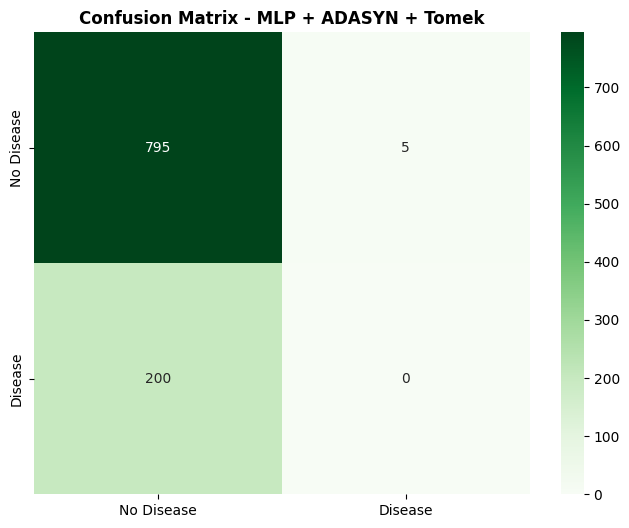

✓ Saved models


In [11]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import TomekLinks

print("-" * 30)
print('MLP + ADASYN + Tomek Links')
print("-" * 30)

# --- 1. Apply ADASYN + Tomek ---
pipe_at = ImbPipeline([
    ('adasyn', ADASYN(random_state=42)),
    ('tomek', TomekLinks())
])
print("Resampling with ADASYN + Tomek...")
X_train_at, y_train_at = pipe_at.fit_resample(X_train_np, y_train_np)

print(f"Original size: {len(X_train_np)}")
print(f"After ADASYN+Tomek size: {len(X_train_at)}")
print("-" * 30)

# --- 2. Cross-Validation ---
cv_scores = []
print("Performing Cross-Validation...")
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_np, y_train_np), 1):
    X_train_fold, X_val_fold = X_train_np[train_idx], X_train_np[val_idx]
    y_train_fold, y_val_fold = y_train_np[train_idx], y_train_np[val_idx]
    
    # Resample only training fold
    X_train_res, y_train_res = pipe_at.fit_resample(X_train_fold, y_train_fold)
    
    model_fold = create_mlp_model(X_train.shape[1])
    model_fold.fit(
        X_train_res, y_train_res,
        validation_data=(X_val_fold, y_val_fold),
        epochs=50, batch_size=32,
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
        verbose=0
    )
    eval_res = model_fold.evaluate(X_val_fold, y_val_fold, verbose=0)
    cv_scores.append(eval_res[1])
    print(f"Fold {fold}: {eval_res[1]:.4f}")

print(f">> Average CV Accuracy: {np.mean(cv_scores):.4f}")
print("-" * 30)

# --- 3. Full Training ---
print("Training MLP with ADASYN+Tomek (Full)...")
mlp_at = create_mlp_model(X_train.shape[1])
history_at = mlp_at.fit(
    X_train_at, y_train_at,
    validation_split=0.2,
    epochs=100, batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=0
)

# --- 4. Evaluation ---
eval_res = mlp_at.evaluate(X_test_np, y_test_np, verbose=0)
test_accuracy = eval_res[1]

y_pred_proba = mlp_at.predict(X_test_np, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

test_precision = precision_score(y_test_np, y_pred)
test_recall = recall_score(y_test_np, y_pred)
test_f1 = f1_score(y_test_np, y_pred)
test_roc_auc = roc_auc_score(y_test_np, y_pred_proba)

# Show Results
print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (ADASYN + Tomek)")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test_np, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - MLP + ADASYN + Tomek', fontweight='bold')
plt.show()

# Save Results
mlp_adasyn_tomek_results = {
    'Model': 'MLP', 'Sampling': 'ADASYN+Tomek',
    'CV_Accuracy': np.mean(cv_scores), 'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy, 'Precision': test_precision,
    'Recall': test_recall, 'F1_Score': test_f1, 'ROC_AUC': test_roc_auc
}

mlp_at.save('mlp/models/MLP_adasyn_tomek.h5')
joblib.dump(pipe_at, 'mlp/models/adasyn_tomek_sampler_mlp.pkl')
print("✓ Saved models")

------------------------------
MLP + BorderlineSMOTE + Tomek Links
------------------------------
Resampling with Borderline+Tomek...


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Original size: 9000
After Borderline+Tomek size: 14272
------------------------------
Performing Cross-Validation...


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...


Epoch 50: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.



Epoch 89: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.



Epoch 94: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.


Restoring model weights from the end of the best epoch: 100.



TEST SET PERFORMANCE (Borderline + Tomek)
Accuracy:  0.6530
Precision: 0.2140
Recall:    0.2750
F1-Score:  0.2407
ROC-AUC:   0.5087


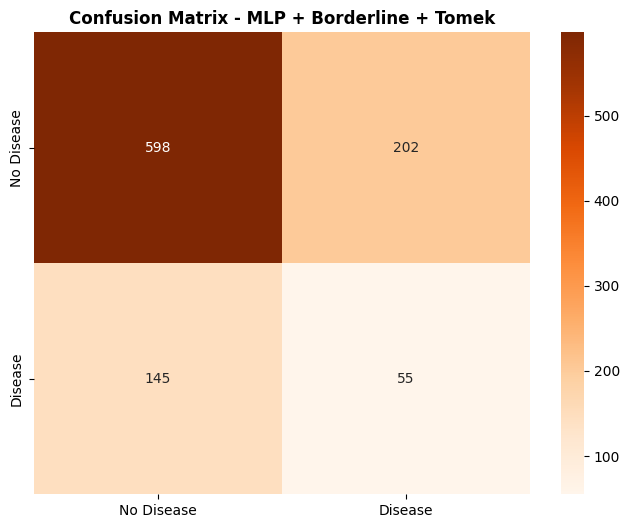

✓ Saved models


In [12]:
from imblearn.over_sampling import BorderlineSMOTE

print("-" * 30)
print('MLP + BorderlineSMOTE + Tomek Links')
print("-" * 30)

# --- 1. Apply Borderline+Tomek ---
pipe_bt = ImbPipeline([
    ('borderline', BorderlineSMOTE(random_state=42, kind='borderline-2')),
    ('tomek', TomekLinks())
])
print("Resampling with Borderline+Tomek...")
X_train_bt, y_train_bt = pipe_bt.fit_resample(X_train_np, y_train_np)

print(f"Original size: {len(X_train_np)}")
print(f"After Borderline+Tomek size: {len(X_train_bt)}")
print("-" * 30)

# --- 2. Cross-Validation ---
cv_scores = []
print("Performing Cross-Validation...")
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_np, y_train_np), 1):
    X_train_fold, X_val_fold = X_train_np[train_idx], X_train_np[val_idx]
    y_train_fold, y_val_fold = y_train_np[train_idx], y_train_np[val_idx]
    
    X_train_res, y_train_res = pipe_bt.fit_resample(X_train_fold, y_train_fold)
    
    model_fold = create_mlp_model(X_train.shape[1])
    model_fold.fit(
        X_train_res, y_train_res,
        validation_data=(X_val_fold, y_val_fold),
        epochs=50, batch_size=32,
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
        verbose=0
    )
    eval_res = model_fold.evaluate(X_val_fold, y_val_fold, verbose=0)
    cv_scores.append(eval_res[1])
    print(f"Fold {fold}: {eval_res[1]:.4f}")

print(f">> Average CV Accuracy: {np.mean(cv_scores):.4f}")
print("-" * 30)

# --- 3. Full Training ---
print("Training MLP with Borderline+Tomek (Full)...")
mlp_bt = create_mlp_model(X_train.shape[1])
history_bt = mlp_bt.fit(
    X_train_bt, y_train_bt,
    validation_split=0.2,
    epochs=100, batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=0
)

# --- 4. Evaluation ---
eval_res = mlp_bt.evaluate(X_test_np, y_test_np, verbose=0)
test_accuracy = eval_res[1]

y_pred_proba = mlp_bt.predict(X_test_np, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

test_precision = precision_score(y_test_np, y_pred)
test_recall = recall_score(y_test_np, y_pred)
test_f1 = f1_score(y_test_np, y_pred)
test_roc_auc = roc_auc_score(y_test_np, y_pred_proba)

# Show Results
print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (Borderline + Tomek)")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test_np, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - MLP + Borderline + Tomek', fontweight='bold')
plt.show()

# Save Results
mlp_borderline_tomek_results = {
    'Model': 'MLP', 'Sampling': 'Borderline+Tomek',
    'CV_Accuracy': np.mean(cv_scores), 'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy, 'Precision': test_precision,
    'Recall': test_recall, 'F1_Score': test_f1, 'ROC_AUC': test_roc_auc
}

mlp_bt.save('mlp/models/MLP_borderline_tomek.h5')
joblib.dump(pipe_bt, 'mlp/models/borderline_tomek_sampler_mlp.pkl')
print("✓ Saved models")


MLP - COMPREHENSIVE SUMMARY
Model           Sampling  CV_Accuracy   CV_Std  Best_Fold  Best_Fold_Val_Acc  Test_Accuracy  Precision  Recall  F1_Score  ROC_AUC
  MLP    None (Baseline)     0.800000 0.000000        1.0           0.800000          0.800   0.000000   0.000  0.000000 0.498769
  MLP              SMOTE     0.538222 0.037470        2.0           0.602778          0.583   0.210667   0.395  0.274783 0.517388
  MLP             ADASYN     0.533778 0.009727        3.0           0.545556          0.522   0.211618   0.510  0.299120 0.526263
  MLP RandomUnderSampler     0.701444 0.091536        4.0           0.795556          0.797   0.285714   0.010  0.019324 0.537781
  MLP         SMOTETomek     0.507889 0.070160        2.0           0.569444          0.545   0.197150   0.415  0.267311 0.507844
  MLP           SMOTEENN     0.208667 0.009274        3.0           0.222222          0.228   0.202083   0.970  0.334483 0.498950
  MLP           NearMiss     0.796111 0.009678        NaN    

/var/folders/pb/8b1j14m116723lhg0z_g3nnm0000gn/T/ipykernel_14604/2607600070.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(mlp_df['Sampling'], rotation=45, ha='right')
/var/folders/pb/8b1j14m116723lhg0z_g3nnm0000gn/T/ipykernel_14604/2607600070.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(mlp_df['Sampling'], rotation=45, ha='right')
/var/folders/pb/8b1j14m116723lhg0z_g3nnm0000gn/T/ipykernel_14604/2607600070.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(mlp_df['Sampling'], rotation=45, ha='right')
/var/folders/pb/8b1j14m116723lhg0z_g3nnm0000gn/T/ipykernel_14604/2607600070.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. a

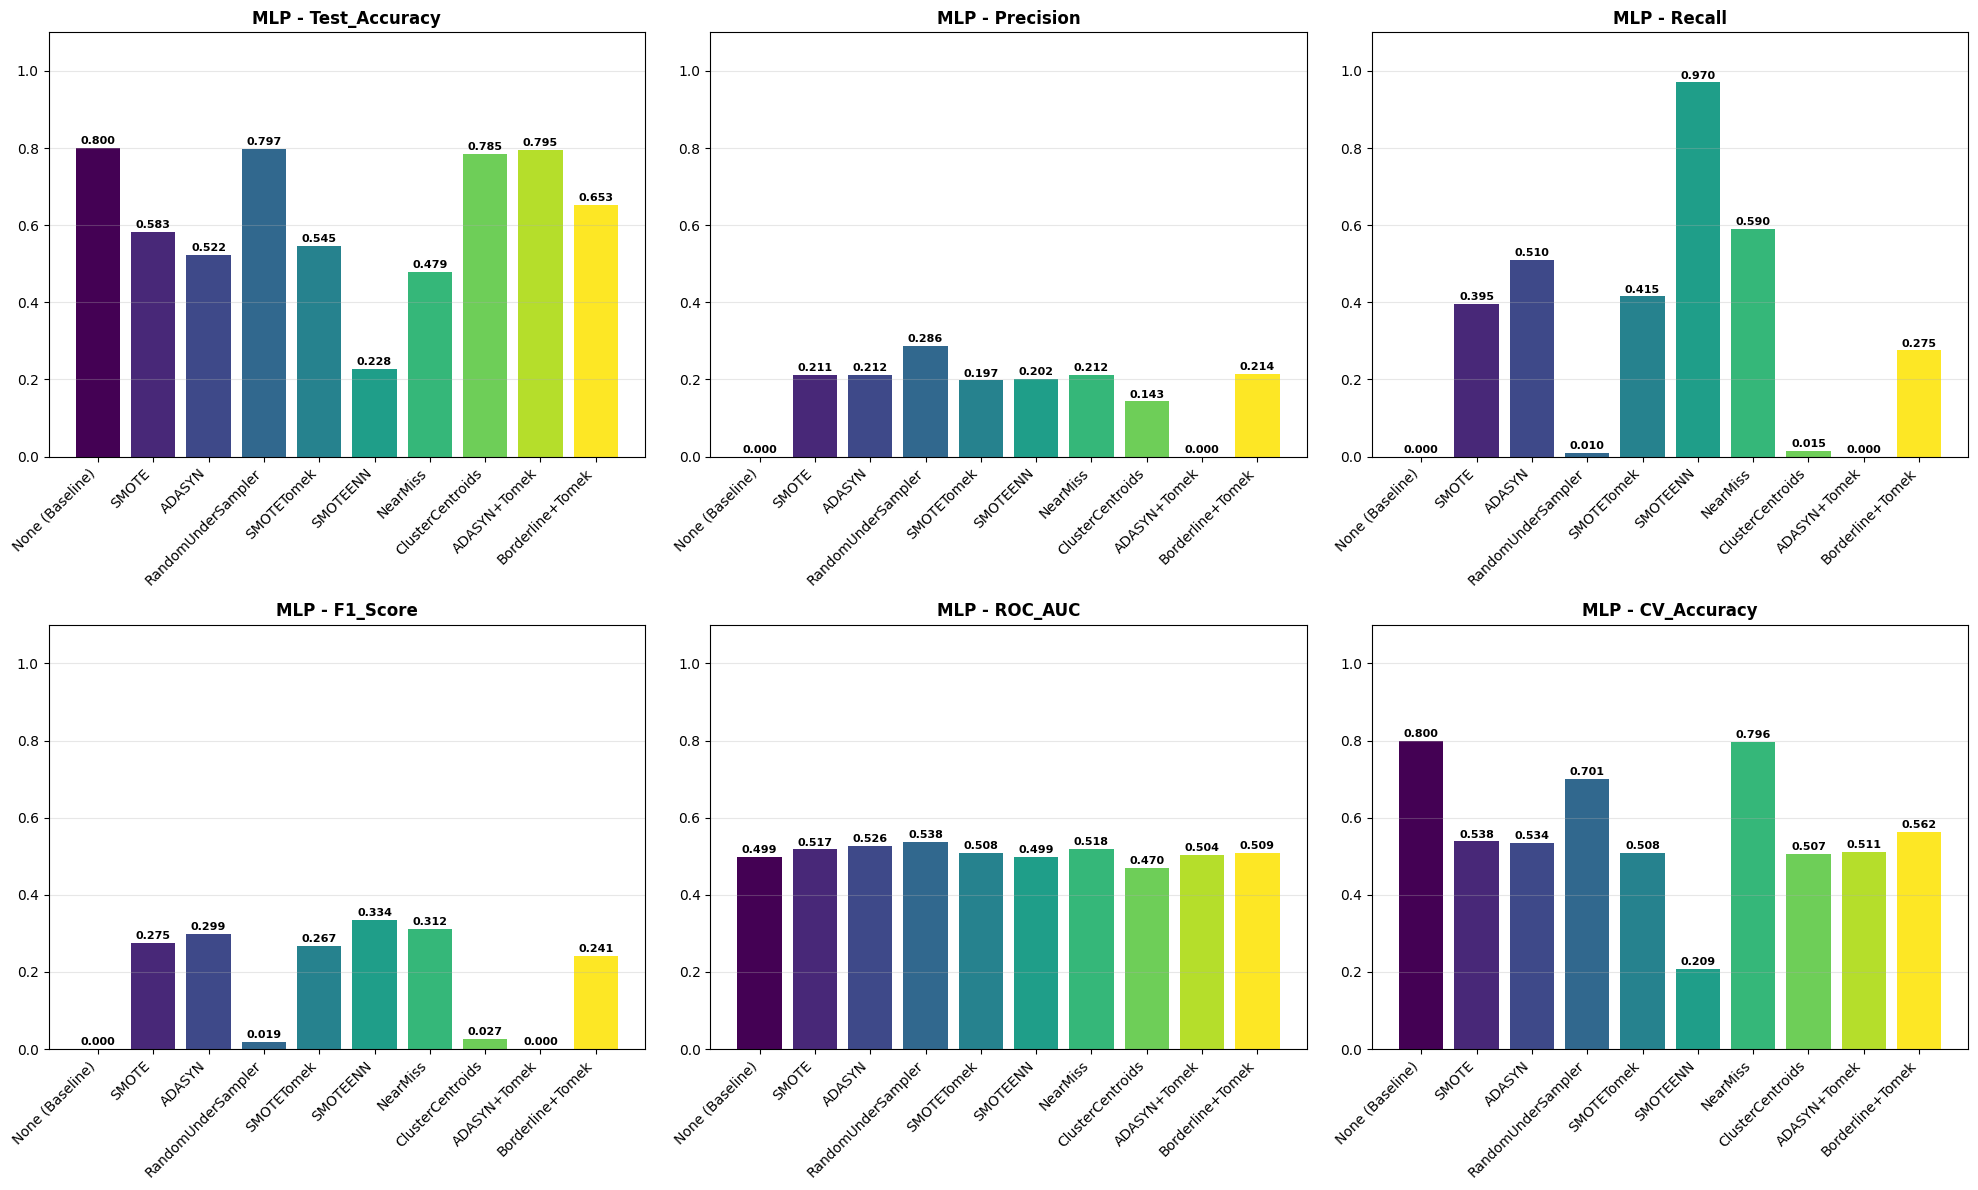


🏆 BEST MLP MODEL
Best by F1-Score: SMOTEENN (0.3345)


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# 1. รวบรวมผลลัพธ์ (เช็คชื่อตัวแปรเก่าให้ครบนะครับ)
mlp_all_results = [
    mlp_baseline_results,
    mlp_smote_results,
    mlp_adasyn_results,
    mlp_rus_results, 
    mlp_smote_tomek_results,
    mlp_smote_enn_results, 
    
    # ของใหม่
    mlp_nearmiss_results,
    mlp_cc_results,
    mlp_adasyn_tomek_results,
    mlp_borderline_tomek_results
]

# 2. สร้าง DataFrame
mlp_df = pd.DataFrame(mlp_all_results)

print("\n" + "=" * 90)
print("MLP - COMPREHENSIVE SUMMARY")
print("=" * 90)
print(mlp_df.to_string(index=False))

# 3. Save CSV
os.makedirs('mlp/models', exist_ok=True)
mlp_df.to_csv('mlp/models/mlp_summary.csv', index=False)
print("✓ Saved summary CSV")

# 4. Visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()
metrics = ['Test_Accuracy', 'Precision', 'Recall', 'F1_Score', 'ROC_AUC', 'CV_Accuracy']
colors = plt.cm.viridis(np.linspace(0, 1, len(mlp_df)))

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    if metric in mlp_df.columns:
        bars = ax.bar(mlp_df['Sampling'], mlp_df[metric], color=colors)
        ax.set_title(f'MLP - {metric}', fontsize=12, fontweight='bold')
        ax.set_xticklabels(mlp_df['Sampling'], rotation=45, ha='right')
        ax.set_ylim([0, 1.1])
        ax.grid(axis='y', alpha=0.3)
        
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01, 
                    f'{bar.get_height():.3f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('mlp/models/mlp_comparison_plot.png', dpi=300)
plt.show()

# 5. Best Model Recommendation
print("\n" + "=" * 90)
print("🏆 BEST MLP MODEL")
print("=" * 90)
best_f1_idx = mlp_df['F1_Score'].idxmax()
print(f"Best by F1-Score: {mlp_df.loc[best_f1_idx, 'Sampling']} ({mlp_df.loc[best_f1_idx, 'F1_Score']:.4f})")